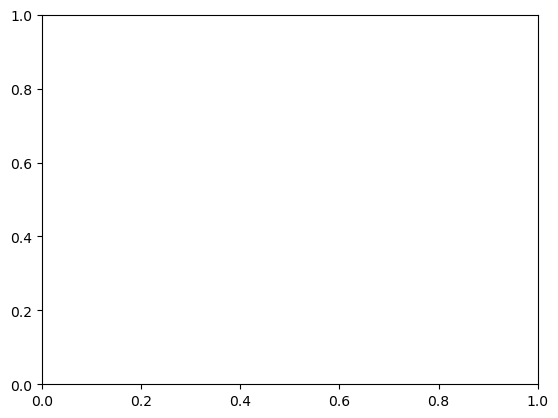

In [1]:
import meep as mp

cell = mp.Vector3(16,16,0)

geometry = [mp.Block(mp.Vector3(12,1,mp.inf),
                     center=mp.Vector3(-2.5,-3.5),
                     material=mp.Medium(epsilon=12)),
            mp.Block(mp.Vector3(1,12,mp.inf),
                     center=mp.Vector3(3.5,2),
                     material=mp.Medium(epsilon=12))]

pml_layers = [mp.PML(1.0)]

resolution = 10

sources = [mp.Source(mp.ContinuousSource(wavelength=2*(11**0.5), width=20),
                     component=mp.Ez,
                     center=mp.Vector3(-7,-3.5),
                     size=mp.Vector3(0,1))]

animate = mp.Animate2D(fields=mp.Ez,
                       field_parameters={'alpha':0.8, 'cmap':'RdBu', 'interpolation':'none'},
                       boundary_parameters={'hatch':'o', 'linewidth':1.5, 'facecolor':'y', 'edgecolor':'b', 'alpha':0.3})


In [23]:
sim = mp.Simulation(cell_size=cell,
                    boundary_layers=pml_layers,
                    geometry=geometry,
                    sources=sources,
                    resolution=resolution)

sim.run(mp.at_beginning(mp.output_epsilon),
        mp.at_every(200,animate),
        until=200)

-----------
Initializing structure...
time for choose_chunkdivision = 0.000132084 s
Working in 2D dimensions.
Computational cell is 16 x 16 x 0 with resolution 10
     block, center = (-2.5,-3.5,0)
          size (12,1,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (12,12,12)
     block, center = (3.5,2,0)
          size (1,12,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (12,12,12)
time for set_epsilon = 0.0344319 s
-----------


FloatProgress(value=0.0, description='0% done ', max=200.0)

creating output file "./eps-000000.00.h5"...
run 0 finished at t = 200.0 (4000 timesteps)


In [22]:
animate.to_mp4(fps=60,filename='meepvideo.mp4')


Generating MP4...


In [ ]:
import numpy as np
import matplotlib.pyplot as plt


In [ ]:
eps_data = sim.get_array(center=mp.Vector3(), size=cell, component=mp.Dielectric)
plt.figure()
plt.imshow(eps_data, interpolation='spline36', cmap='binary')
plt.axis('off')
plt.show()

In [ ]:
ez_data = sim.get_array(center=mp.Vector3(), size=cell, component=mp.Ez)
plt.figure()
plt.imshow(eps_data.transpose(), interpolation='spline36', cmap='binary')
plt.imshow(ez_data.transpose(), interpolation='spline36', cmap='RdBu', alpha=0.9)
plt.axis('off')
plt.show()

In [ ]:
sim.plot2D(fields=mp.Ez,
           field_parameters={'alpha':0.8, 'cmap':'RdBu', 'interpolation':'none'},
           boundary_parameters={'hatch':'o', 'linewidth':1.5, 'facecolor':'y', 'edgecolor':'b', 'alpha':0.3})
plt.show()
plt.savefig('sim_domain.png')